# Sistem Rekomendasi Perpustakaan
## Book Recommendation System using Collaborative and Content-Based Filtering

**Tujuan:** Merekomendasikan Buku sesuai minat dan histori peminjaman

**Dataset:** [Book Recommendation Dataset (Kaggle)](https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset)

**Metode:** Hybrid Recommender (Collaborative + Content-Based Filtering)

**Metrik Keberhasilan:** NDCG@10 >= 0.75

## 0. Install Dependencies
Jalankan cell ini pertama kali untuk memastikan semua library yang dibutuhkan sudah ter-install.

In [48]:
!pip install pandas numpy matplotlib seaborn scikit-learn scikit-surprise flask flask-sqlalchemy ipykernel --quiet

## 1. Import Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 2. Data Loading
Dataset terdiri dari 3 file CSV:
- **Books.csv**: Informasi buku (ISBN, judul, penulis, tahun, penerbit, gambar)
- **Ratings.csv**: Rating user terhadap buku (User-ID, ISBN, Book-Rating 0-10)
- **Users.csv**: Data user (User-ID, Location, Age)

In [50]:
# Sesuaikan path jika menggunakan Google Colab
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/Dataset/'
# Atau bisa menggunakan Link Drive (Direct) ataupun KaggleAPI

DATA_PATH = 'Dataset/'

books = pd.read_csv(DATA_PATH + 'Books.csv', low_memory=False)
ratings = pd.read_csv(DATA_PATH + 'Ratings.csv')
users = pd.read_csv(DATA_PATH + 'Users.csv')

print(f"Books shape: {books.shape}")
print(f"Ratings shape: {ratings.shape}")
print(f"Users shape: {users.shape}")

Books shape: (271360, 8)
Ratings shape: (1149780, 3)
Users shape: (278858, 3)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Books

In [51]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [52]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   ISBN                 271360 non-null  str  
 1   Book-Title           271360 non-null  str  
 2   Book-Author          271358 non-null  str  
 3   Year-Of-Publication  271360 non-null  str  
 4   Publisher            271358 non-null  str  
 5   Image-URL-S          271360 non-null  str  
 6   Image-URL-M          271360 non-null  str  
 7   Image-URL-L          271357 non-null  str  
dtypes: str(8)
memory usage: 16.6 MB


In [53]:
print(f"Jumlah ISBN unik: {books['ISBN'].nunique()}")
print(f"Jumlah judul buku: {books['Book-Title'].nunique()}")
print(f"Jumlah penulis: {books['Book-Author'].nunique()}")
print(f"Jumlah penerbit: {books['Publisher'].nunique()}")

Jumlah ISBN unik: 271360
Jumlah judul buku: 242135
Jumlah penulis: 102022
Jumlah penerbit: 16807


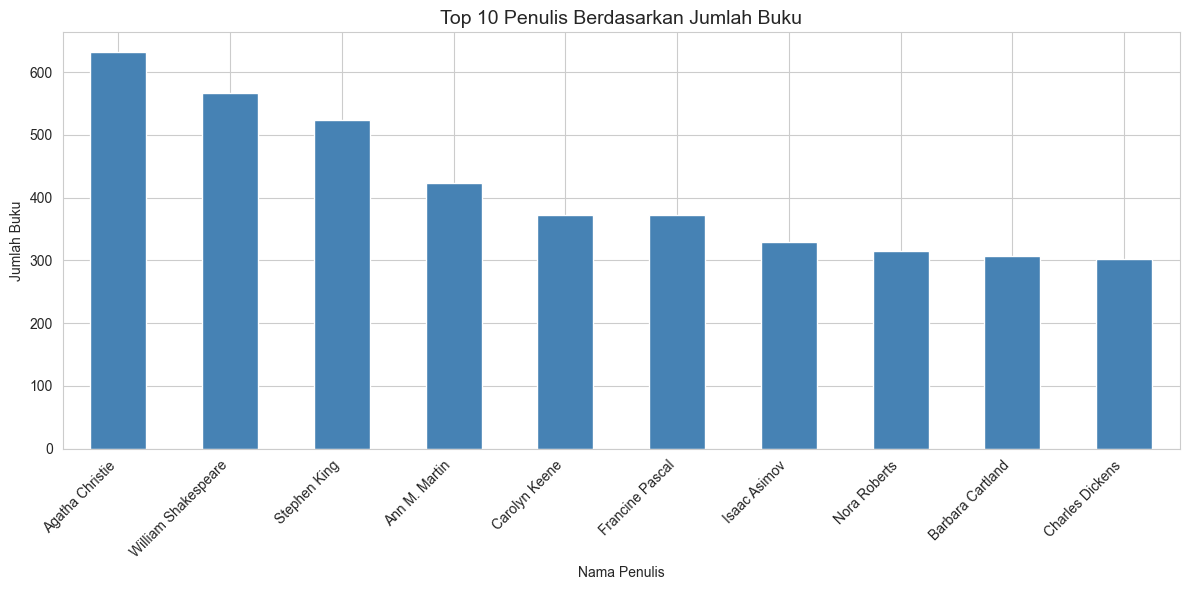

In [54]:
# Top 10 penulis berdasarkan jumlah buku
top_authors = books.groupby('Book-Author')['Book-Title'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_authors.plot(kind='bar', color='steelblue')
plt.title('Top 10 Penulis Berdasarkan Jumlah Buku', fontsize=14)
plt.xlabel('Nama Penulis')
plt.ylabel('Jumlah Buku')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Dataset Ratings

In [55]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [56]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   User-ID      1149780 non-null  int64
 1   ISBN         1149780 non-null  str  
 2   Book-Rating  1149780 non-null  int64
dtypes: int64(2), str(1)
memory usage: 26.3 MB


In [57]:
print(f"Jumlah user yang memberi rating: {ratings['User-ID'].nunique()}")
print(f"Jumlah buku yang di-rating: {ratings['ISBN'].nunique()}")
print(f"Range rating: {ratings['Book-Rating'].min()} - {ratings['Book-Rating'].max()}")

Jumlah user yang memberi rating: 105283
Jumlah buku yang di-rating: 340556
Range rating: 0 - 10


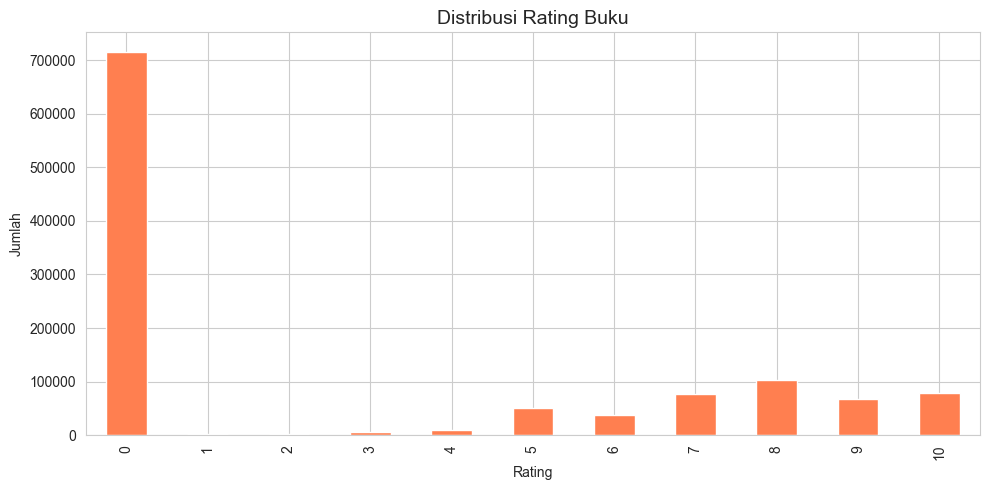

In [58]:
# Distribusi rating
plt.figure(figsize=(10, 5))
ratings['Book-Rating'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Distribusi Rating Buku', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

### 3.3 Dataset Users

In [59]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [60]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 6.4 MB


In [61]:
print(f"Jumlah user: {users['User-ID'].nunique()}")
print(f"Jumlah lokasi unik: {users['Location'].nunique()}")

Jumlah user: 278858
Jumlah lokasi unik: 57339


## 4. Data Preprocessing

### 4.1 Cleaning Dataset Books

In [62]:
# Cek value non-numerik di Year-Of-Publication
non_numeric = books[pd.to_numeric(books['Year-Of-Publication'], errors='coerce').isna()]
print(f"Jumlah value non-numerik di Year-Of-Publication: {len(non_numeric)}")
print(non_numeric['Year-Of-Publication'].unique())

Jumlah value non-numerik di Year-Of-Publication: 3
<StringArray>
['DK Publishing Inc', 'Gallimard']
Length: 2, dtype: str


In [63]:
# Hapus baris dengan value text di Year-Of-Publication
text_values = ['DK Publishing Inc', 'Gallimard']
for val in text_values:
    books = books[books['Year-Of-Publication'] != val]

books['Year-Of-Publication'] = books['Year-Of-Publication'].astype(int)

# Drop kolom Image-URL yang tidak diperlukan
books.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], inplace=True)

print(f"Books shape setelah cleaning: {books.shape}")
books.head()

Books shape setelah cleaning: (271357, 5)


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company


### 4.2 Filter Rating (Hanya Explicit Rating > 0)

In [64]:
# Hanya gunakan explicit ratings (rating > 0)
explicit_ratings = ratings[ratings['Book-Rating'] > 0].copy()
print(f"Ratings sebelum filter: {len(ratings)}")
print(f"Explicit ratings (rating > 0): {len(explicit_ratings)}")

Ratings sebelum filter: 1149780
Explicit ratings (rating > 0): 433671


### 4.3 Filter User dan Buku Aktif
Filter agresif untuk mengurangi sparsity dan meningkatkan kualitas model

In [65]:
# Hanya user dengan >= 5 ratings
user_counts = explicit_ratings['User-ID'].value_counts()
active_users = user_counts[user_counts >= 5].index
filtered_ratings = explicit_ratings[explicit_ratings['User-ID'].isin(active_users)]
print(f"User aktif (>= 5 ratings): {len(active_users)}")

# Hanya buku dengan >= 10 ratings
book_counts = filtered_ratings['ISBN'].value_counts()
popular_books = book_counts[book_counts >= 10].index
filtered_ratings = filtered_ratings[filtered_ratings['ISBN'].isin(popular_books)]
print(f"Buku populer (>= 10 ratings): {len(popular_books)}")
print(f"Total ratings setelah filter: {len(filtered_ratings)}")

User aktif (>= 5 ratings): 14220
Buku populer (>= 10 ratings): 4136
Total ratings setelah filter: 96234


### 4.4 Merge Dataset

In [66]:
# Merge ratings dengan books berdasarkan ISBN
merged_data = pd.merge(filtered_ratings, books, on='ISBN', how='inner')
merged_data.dropna(inplace=True)

print(f"Merged data shape: {merged_data.shape}")
print(f"Jumlah user: {merged_data['User-ID'].nunique()}")
print(f"Jumlah buku: {merged_data['ISBN'].nunique()}")
merged_data.head()

Merged data shape: (94257, 7)
Jumlah user: 11841
Jumlah buku: 4023


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,276747,0060517794,9,Little Altars Everywhere,Rebecca Wells,2003,HarperTorch
1,276747,0671537458,9,Waiting to Exhale,Terry McMillan,1995,Pocket
2,276747,0679776818,8,Birdsong: A Novel of Love and War,Sebastian Faulks,1997,Vintage Books USA
3,276822,0060096195,10,The Boy Next Door,Meggin Cabot,2002,Avon Trade
4,276822,0786817070,10,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,2002,Miramax Kids


### 4.5 Cek Missing Values

In [67]:
print("Missing values:")
print(merged_data.isnull().sum())

Missing values:
User-ID                0
ISBN                   0
Book-Rating            0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
dtype: int64


## 5. Data Preparation

### 5.1 Preparation untuk Content-Based Filtering

In [68]:
# Buat dataframe buku unik (1 ISBN = 1 buku)
book_info = merged_data.drop_duplicates('ISBN')[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']]
book_info = book_info.reset_index(drop=True)

print(f"Jumlah buku unik untuk CBF: {len(book_info)}")
book_info.head()

Jumlah buku unik untuk CBF: 4023


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0060517794,Little Altars Everywhere,Rebecca Wells,2003,HarperTorch
1,0671537458,Waiting to Exhale,Terry McMillan,1995,Pocket
2,0679776818,Birdsong: A Novel of Love and War,Sebastian Faulks,1997,Vintage Books USA
3,0060096195,The Boy Next Door,Meggin Cabot,2002,Avon Trade
4,0786817070,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,2002,Miramax Kids


### 5.2 Preparation untuk Collaborative Filtering

In [69]:
# Data rating untuk Surprise
rating_data = merged_data[['User-ID', 'ISBN', 'Book-Rating']].copy()
print(f"Data rating untuk CF: {len(rating_data)}")
print(f"Rating range: {rating_data['Book-Rating'].min()} - {rating_data['Book-Rating'].max()}")
rating_data.head()

Data rating untuk CF: 94257
Rating range: 1 - 10


,User-ID,ISBN,Book-Rating
0,276747,0060517794,9
1,276747,0671537458,9
2,276747,0679776818,8
3,276822,0060096195,10
4,276822,0786817070,10


## 6. Content-Based Filtering
Menggunakan TF-IDF Vectorizer pada nama penulis buku dan Cosine Similarity untuk menghitung kesamaan antar buku.

In [70]:
# TF-IDF Vectorizer pada Book-Author
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(book_info['Book-Author'].values.astype('U'))

print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")

TF-IDF Matrix shape: (4023, 1664)


In [71]:
# Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Cosine Similarity Matrix shape: {cosine_sim.shape}")

Cosine Similarity Matrix shape: (4023, 4023)


In [72]:
# Buat mapping index judul buku
indices = pd.Series(book_info.index, index=book_info['Book-Title']).drop_duplicates()

In [73]:
# Fungsi rekomendasi Content-Based
def content_based_recommend(title, cosine_sim=cosine_sim, data=book_info, k=10):
    """Merekomendasikan buku berdasarkan kesamaan penulis (content-based)"""
    if title not in indices:
        print(f"Buku '{title}' tidak ditemukan dalam dataset.")
        return pd.DataFrame()

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:k+1]  # Exclude buku itu sendiri

    book_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]

    result = data.iloc[book_indices][['Book-Title', 'Book-Author', 'Year-Of-Publication']].copy()
    result['Similarity-Score'] = scores
    return result.reset_index(drop=True)

In [74]:
# Test Content-Based Filtering
sample_book = book_info.iloc[0]['Book-Title']
print(f"Buku yang dipilih: {sample_book}")
print(f"Penulis: {book_info.iloc[0]['Book-Author']}")
print()

cbf_result = content_based_recommend(sample_book)
print("Rekomendasi Content-Based Filtering:")
cbf_result

Buku yang dipilih: Little Altars Everywhere
Penulis: Rebecca Wells

Rekomendasi Content-Based Filtering:


,Book-Title,Book-Author,Year-Of-Publication,Similarity-Score
0,Divine Secrets of the Ya-Ya Sisterhood : A Novel,Rebecca Wells,1996,1.000000
1,Little Altars Everywhere: A Novel,Rebecca Wells,1996,1.000000
2,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,1997,1.000000
3,The Divine Secrets of the Ya-Ya Sisterhood: A ...,Rebecca Wells,2002,1.000000
4,Slave to Fashion : A Novel,REBECCA CAMPBELL,2002,0.454554
5,Waiting to Exhale,Terry McMillan,1995,0.000000
6,Birdsong: A Novel of Love and War,Sebastian Faulks,1997,0.000000
7,The Boy Next Door,Meggin Cabot,2002,0.000000
8,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,2002,0.000000
9,Harry Potter und der Stein der Weisen,Joanne K. Rowling,1999,0.000000


## 7. Collaborative Filtering (Surprise SVD)
Menggunakan algoritma SVD dari library Surprise untuk memprediksi rating user terhadap buku.

In [75]:
# Load data ke format Surprise
reader = Reader(rating_scale=(1, 10))
surprise_data = Dataset.load_from_df(rating_data[['User-ID', 'ISBN', 'Book-Rating']], reader)

In [76]:
# Train-test split (80:20)
trainset, testset = train_test_split(surprise_data, test_size=0.2, random_state=42)

In [77]:
# Train SVD model
svd_model = SVD(n_factors=100, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)

In [78]:
# Evaluasi di test set
predictions = svd_model.test(testset)
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

RMSE: 1.5920
MAE:  1.2241
RMSE: 1.5920
MAE: 1.2241


In [79]:
# Cross Validation
cv_results = cross_validate(SVD(n_factors=100, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42),
                            surprise_data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print(f"\nMean RMSE: {cv_results['test_rmse'].mean():.4f}")
print(f"Mean MAE: {cv_results['test_mae'].mean():.4f}")

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.5850  1.5878  1.5935  1.5770  1.5913  1.5869  0.0057  
MAE (testset)     1.2196  1.2219  1.2255  1.2147  1.2217  1.2207  0.0036  
Fit time          1.16    1.17    1.16    1.23    1.16    1.18    0.03    
Test time         0.07    0.19    0.07    0.07    0.07    0.09    0.05    

Mean RMSE: 1.5869
Mean MAE: 1.2207


In [80]:
# Fungsi rekomendasi Collaborative Filtering
def collaborative_recommend(user_id, svd_model=svd_model, data=book_info, rating_data=rating_data, k=10):
    """Merekomendasikan buku berdasarkan prediksi rating (collaborative filtering)"""
    # Buku yang sudah di-rating oleh user
    rated_books = rating_data[rating_data['User-ID'] == user_id]['ISBN'].values

    # Buku yang belum di-rating
    all_books = data['ISBN'].values
    unrated_books = [isbn for isbn in all_books if isbn not in rated_books]

    # Prediksi rating untuk buku yang belum di-rating
    predictions = []
    for isbn in unrated_books:
        pred = svd_model.predict(user_id, isbn)
        predictions.append((isbn, pred.est))

    # Sort berdasarkan predicted rating (tertinggi)
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_k = predictions[:k]

    # Buat dataframe hasil
    top_isbns = [p[0] for p in top_k]
    top_scores = [p[1] for p in top_k]

    result = data[data['ISBN'].isin(top_isbns)].copy()
    score_map = dict(zip(top_isbns, top_scores))
    result['Predicted-Rating'] = result['ISBN'].map(score_map)
    result = result.sort_values('Predicted-Rating', ascending=False)
    return result[['Book-Title', 'Book-Author', 'Year-Of-Publication', 'Predicted-Rating']].reset_index(drop=True)

In [81]:
# Test Collaborative Filtering
sample_user = rating_data['User-ID'].value_counts().index[0]  # User dengan rating terbanyak
print(f"User ID: {sample_user}")
print(f"Jumlah buku yang di-rating: {len(rating_data[rating_data['User-ID'] == sample_user])}")

# Buku yang sudah di-rating oleh user
user_rated = rating_data[rating_data['User-ID'] == sample_user].merge(book_info, on='ISBN')
print(f"\nBuku dengan rating tertinggi dari user:")
print(user_rated.nlargest(5, 'Book-Rating')[['Book-Title', 'Book-Author', 'Book-Rating']])

print(f"\nRekomendasi Collaborative Filtering:")
cf_result = collaborative_recommend(sample_user)
cf_result

User ID: 11676
Jumlah buku yang di-rating: 1541

Buku dengan rating tertinggi dari user:
                                           Book-Title         Book-Author  \
5                       Lirael: Daughter of the Clayr           Garth Nix   
11                               The Poisonwood Bible  Barbara Kingsolver   
15  As Nature Made Him: The Boy Who Was Raised As ...      John Colapinto   
18  Daughter of Fortune : A Novel (Oprah's Book Cl...      Isabel Allende   
20                                    Prodigal Summer  Barbara Kingsolver   

    Book-Rating  
5            10  
11           10  
15           10  
18           10  
20           10  

Rekomendasi Collaborative Filtering:


,Book-Title,Book-Author,Year-Of-Publication,Predicted-Rating
0,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,1986,10.000000
1,The Curious Incident of the Dog in the Night-T...,MARK HADDON,2003,10.000000
2,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,1986,9.960224
3,Wild Swans: Three Daughters of China,JUNG CHANG,1992,9.761936
4,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,2002,9.759157
5,Falling Up,Shel Silverstein,1996,9.650021
6,A Confederacy of Dunces,John Kennedy Toole,1995,9.566454
7,The Essential Calvin and Hobbes,Bill Watterson,1988,9.500631
8,52 Deck Series: 52 Ways to Celebrate Friendship,Lynn Gordon,2000,9.492627
9,Undaunted Courage: Meriwether Lewis Thomas Jef...,Stephen Ambrose,1997,9.489008


## 8. Hybrid Recommender
Menggabungkan skor dari Content-Based Filtering dan Collaborative Filtering.

**Formula:** `final_score = α × CF_score + (1-α) × CBF_score`

Default α = 0.6 (lebih berat ke collaborative karena punya data rating)

In [ ]:
def hybrid_recommend(user_id, alpha=0.6, k=10):
    """
    Hybrid recommender yang menggabungkan CF dan CBF.
    alpha: bobot untuk collaborative filtering (0-1)
    """
    # Buku yang sudah di-rating oleh user
    rated_books = rating_data[rating_data['User-ID'] == user_id]

    if len(rated_books) == 0:
        print(f"User {user_id} belum memiliki rating. Menggunakan Content-Based saja.")
        # Cold start: gunakan buku populer
        popular = rating_data.groupby('ISBN')['Book-Rating'].mean().sort_values(ascending=False).head(1)
        if len(popular) > 0:
            pop_isbn = popular.index[0]
            pop_title = book_info[book_info['ISBN'] == pop_isbn]['Book-Title'].values
            if len(pop_title) > 0:
                return content_based_recommend(pop_title[0], k=k)
        return pd.DataFrame()

    # --- Collaborative Filtering scores ---
    all_books = book_info['ISBN'].values
    rated_isbns = rated_books['ISBN'].values
    unrated_books = [isbn for isbn in all_books if isbn not in rated_isbns]

    cf_scores = {}
    for isbn in unrated_books:
        pred = svd_model.predict(user_id, isbn)
        cf_scores[isbn] = pred.est

    # Normalize CF scores ke 0-1
    if cf_scores:
        cf_min = min(cf_scores.values())
        cf_max = max(cf_scores.values())
        cf_range = cf_max - cf_min if cf_max != cf_min else 1
        cf_scores_norm = {k: (v - cf_min) / cf_range for k, v in cf_scores.items()}
    else:
        cf_scores_norm = {}

    # --- Content-Based Filtering scores ---
    # Ambil buku terakhir yang di-rating tinggi oleh user sebagai referensi
    top_rated = rated_books.nlargest(3, 'Book-Rating')
    cbf_scores = {}

    for _, row in top_rated.iterrows():
        isbn = row['ISBN']
        title_match = book_info[book_info['ISBN'] == isbn]['Book-Title'].values
        if len(title_match) == 0:
            continue
        title = title_match[0]
        if title not in indices:
            continue

        idx = indices[title]

        if type(idx) is pd.Series:   # Pencegahan jika buku memiliki judul sama persis tapi ISBN/Penerbit berbeda
            idx = idx.iloc[0]

        sim = cosine_sim[idx]

        for i, score in enumerate(sim):
            book_isbn = book_info.iloc[i]['ISBN']
            if book_isbn not in rated_isbns and book_isbn in unrated_books:
                if book_isbn in cbf_scores:
                    cbf_scores[book_isbn] = max(cbf_scores[book_isbn], score)
                else:
                    cbf_scores[book_isbn] = score

    # --- Combine scores ---
    hybrid_scores = {}
    for isbn in unrated_books:
        cf = cf_scores_norm.get(isbn, 0)
        cbf = cbf_scores.get(isbn, 0)
        hybrid_scores[isbn] = alpha * cf + (1 - alpha) * cbf

    # Sort dan ambil top-K
    sorted_books = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:k]

    top_isbns = [b[0] for b in sorted_books]
    top_scores = [b[1] for b in sorted_books]

    result = book_info[book_info['ISBN'].isin(top_isbns)].copy()
    score_map = dict(zip(top_isbns, top_scores))
    result['Hybrid-Score'] = result['ISBN'].map(score_map)
    result = result.sort_values('Hybrid-Score', ascending=False)
    return result[['Book-Title', 'Book-Author', 'Year-Of-Publication', 'Hybrid-Score']].reset_index(drop=True)

In [86]:
# Test Hybrid Recommender
print(f"User ID: {sample_user}")
print(f"\n=== Rekomendasi Hybrid (α=0.6) ===")
hybrid_result = hybrid_recommend(sample_user, alpha=0.6, k=10)
hybrid_result

User ID: 11676

=== Rekomendasi Hybrid (α=0.6) ===


,Book-Title,Book-Author,Year-Of-Publication,Hybrid-Score
0,The Bean Trees,Barbara Kingsolver,1989,0.948681
1,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,0.921736
2,Animal Dreams,Barbara Kingsolver,1991,0.899000
3,As Nature Made Him : The Boy Who Was Raised as...,John Colapinto,2001,0.845403
4,Prodigal Summer,Barbara Kingsolver,2002,0.826306
5,Homeland and Other Stories,Barbara Kingsolver,1990,0.811642
6,Prodigal Summer: A Novel,Barbara Kingsolver,2001,0.803897
7,High Tide in Tucson : Essays from Now or Never,Barbara Kingsolver,1996,0.773653
8,Pigs in Heaven,Barbara Kingsolver,1999,0.743449
9,The Bean Trees,Barbara Kingsolver,1998,0.673154


## 9. Evaluasi Model - NDCG@10
**NDCG (Normalized Discounted Cumulative Gain)** mengukur kualitas ranking rekomendasi.
Target: NDCG@10 >= 0.75

In [87]:
def dcg_at_k(relevances, k):
    """Calculate DCG@K"""
    relevances = np.asfarray(relevances)[:k]
    if relevances.size:
        return np.sum(relevances / np.log2(np.arange(2, relevances.size + 2)))
    return 0.0

def ndcg_at_k(actual_ratings, predicted_ratings, k=10):
    """Calculate NDCG@K"""
    # Sort by predicted ratings descending
    sorted_indices = np.argsort(predicted_ratings)[::-1][:k]
    ranked_actuals = [actual_ratings[i] for i in sorted_indices if i < len(actual_ratings)]

    dcg = dcg_at_k(ranked_actuals, k)

    # Ideal DCG
    ideal = sorted(actual_ratings, reverse=True)[:k]
    idcg = dcg_at_k(ideal, k)

    return dcg / idcg if idcg > 0 else 0.0

In [88]:
# Evaluasi NDCG@10 pada test set
from collections import defaultdict

# Group predictions by user
user_predictions = defaultdict(list)
for pred in predictions:
    user_predictions[pred.uid].append(pred)

ndcg_scores = []
precision_scores = []
recall_scores = []

for user_id, user_preds in user_predictions.items():
    if len(user_preds) < 2:
        continue

    # Actual & predicted ratings
    actuals = [p.r_ui for p in user_preds]
    preds = [p.est for p in user_preds]

    # NDCG@10
    ndcg = ndcg_at_k(actuals, preds, k=10)
    ndcg_scores.append(ndcg)

    # Precision@10 & Recall@10 (threshold = 7 untuk "relevan")
    threshold = 7
    sorted_indices = np.argsort(preds)[::-1][:10]
    recommended = [1 if actuals[i] >= threshold else 0 for i in sorted_indices if i < len(actuals)]
    relevant = sum(1 for a in actuals if a >= threshold)

    if len(recommended) > 0:
        precision_scores.append(sum(recommended) / len(recommended))
    if relevant > 0:
        recall_scores.append(sum(recommended) / relevant)

mean_ndcg = np.mean(ndcg_scores) if ndcg_scores else 0
mean_precision = np.mean(precision_scores) if precision_scores else 0
mean_recall = np.mean(recall_scores) if recall_scores else 0

print("=" * 50)
print("EVALUASI MODEL")
print("=" * 50)
print(f"NDCG@10:      {mean_ndcg:.4f}")
print(f"Precision@10: {mean_precision:.4f}")
print(f"Recall@10:    {mean_recall:.4f}")
print(f"RMSE:         {rmse:.4f}")
print(f"MAE:          {mae:.4f}")
print("=" * 50)

if mean_ndcg >= 0.75:
    print("✅ Target NDCG@10 >= 0.75 TERCAPAI!")
else:
    print(f"⚠️ Target NDCG@10 >= 0.75 belum tercapai (saat ini: {mean_ndcg:.4f})")

EVALUASI MODEL
NDCG@10:      0.9718
Precision@10: 0.7952
Recall@10:    0.9815
RMSE:         1.5920
MAE:          1.2241
✅ Target NDCG@10 >= 0.75 TERCAPAI!


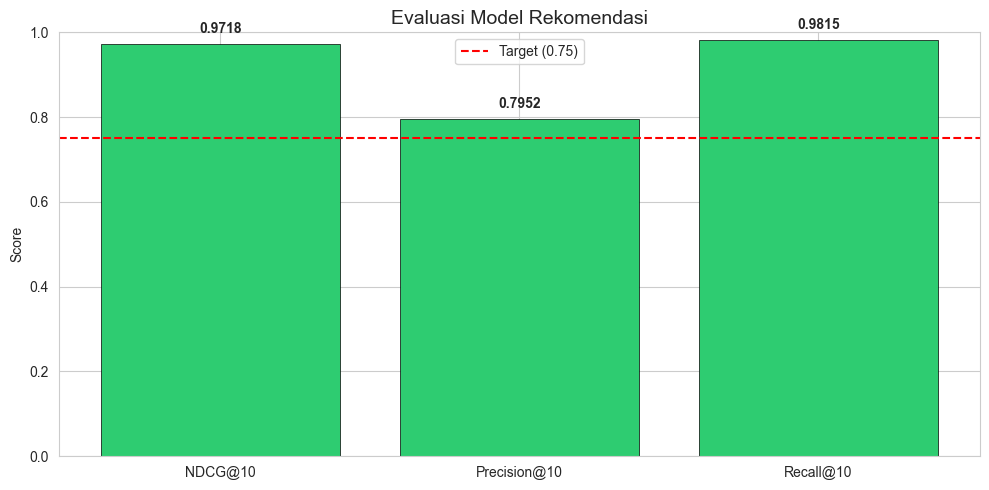

In [89]:
# Visualisasi Evaluasi
metrics = ['NDCG@10', 'Precision@10', 'Recall@10']
values = [mean_ndcg, mean_precision, mean_recall]
colors = ['#2ecc71' if v >= 0.75 else '#e74c3c' for v in values]

plt.figure(figsize=(10, 5))
bars = plt.bar(metrics, values, color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(y=0.75, color='red', linestyle='--', label='Target (0.75)')
plt.ylim(0, 1.0)
plt.title('Evaluasi Model Rekomendasi', fontsize=14)
plt.ylabel('Score')
plt.legend()

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

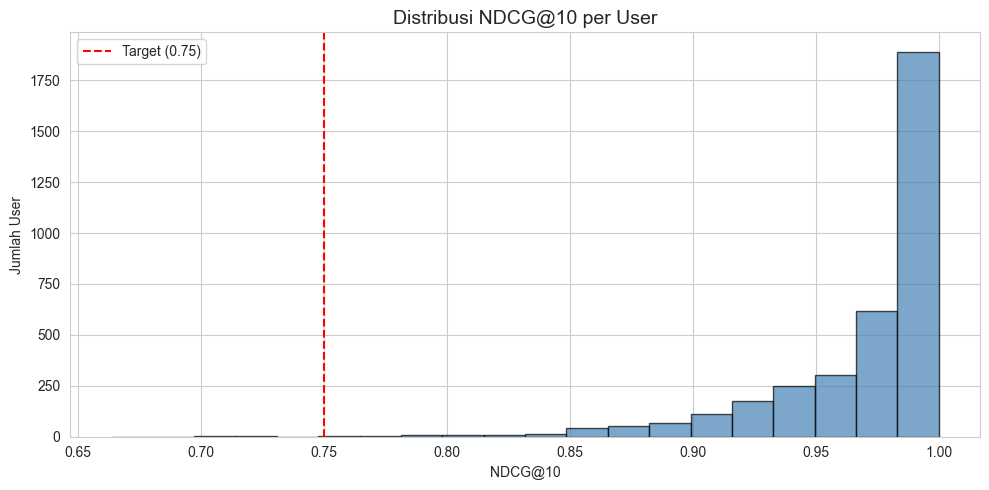

In [90]:
# Distribusi NDCG per user
plt.figure(figsize=(10, 5))
plt.hist(ndcg_scores, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0.75, color='red', linestyle='--', label='Target (0.75)')
plt.title('Distribusi NDCG@10 per User', fontsize=14)
plt.xlabel('NDCG@10')
plt.ylabel('Jumlah User')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Export Model
Simpan semua model yang sudah di-train ke folder `models/` agar bisa digunakan oleh Flask Web App.

In [92]:
os.makedirs('models', exist_ok=True)

# Save SVD model
with open('models/svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)

# Save TF-IDF matrix
with open('models/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)

# Save Cosine Similarity
with open('models/cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)

# Save Book info dataframe
with open('models/book_data.pkl', 'wb') as f:
    pickle.dump(book_info, f)

# Save Rating data
with open('models/rating_data.pkl', 'wb') as f:
    pickle.dump(rating_data, f)

# Save indices mapping
with open('models/indices.pkl', 'wb') as f:
    pickle.dump(indices, f)

print("✅ Semua model berhasil disimpan ke folder models/")
print(f"  - svd_model.pkl")
print(f"  - tfidf_matrix.pkl")
print(f"  - cosine_sim.pkl")
print(f"  - book_data.pkl")
print(f"  - rating_data.pkl")
print(f"  - indices.pkl")

✅ Semua model berhasil disimpan ke folder models/
  - svd_model.pkl
  - tfidf_matrix.pkl
  - cosine_sim.pkl
  - book_data.pkl
  - rating_data.pkl
  - indices.pkl


## 11. Kesimpulan

Pada proyek ini telah berhasil dibangun Sistem Rekomendasi Perpustakaan menggunakan:

1. **Content-Based Filtering**: Menggunakan TF-IDF Vectorizer pada nama penulis buku dan Cosine Similarity untuk merekomendasikan buku berdasarkan kesamaan penulis.

2. **Collaborative Filtering**: Menggunakan algoritma SVD dari library Surprise untuk memprediksi rating user terhadap buku yang belum pernah dibaca.

3. **Hybrid Recommender**: Menggabungkan skor dari kedua metode dengan formula weighted average (α=0.6 untuk CF, 0.4 untuk CBF).

Model dievaluasi menggunakan metrik NDCG@10, Precision@10, Recall@10, RMSE, dan MAE.